## Earning Events by Regime: Visualisation

In [1]:
import pandas as pd
import numpy as np

In [2]:
panel = pd.read_csv('earnings_regression_panel.csv', parse_dates=['Earnings Date'])

In [3]:
panel

,Ticker,Earnings Date,Surprise,CAR,Regime,VIX,Δ10Y
0,GOOGL,2005-04-21,0.0095,0.000635,0,14.41,0.035971
1,NVDA,2005-05-12,0.0040,0.026393,0,16.12,0.027027
2,AAPL,2005-07-13,0.0000,0.001773,0,10.84,-0.047945
3,GOOGL,2005-07-21,0.0035,0.006394,0,10.97,-0.009259
4,NVDA,2005-08-11,0.0000,0.002138,0,12.42,0.033493
...,...,...,...,...,...,...,...
243,AAPL,2025-07-31,0.1400,-0.004975,0,16.72,0.028235
244,NVDA,2025-08-27,0.0400,-0.005637,0,14.85,-0.051454
245,GOOGL,2025-10-29,0.5500,0.019327,0,16.92,-0.068493
246,AAPL,2025-10-30,0.0900,0.023900,0,16.91,-0.059497


In [4]:
panel['year'] = pd.to_datetime(panel['Earnings Date']).dt.year

In [5]:
regime_counts = (
    panel
    .groupby('year')['Regime']
    .value_counts()
    .unstack(fill_value=0)
    .sort_index()
)

regime_counts

Regime,0,1,2
year,,,
2005,8,0,0
2006,12,0,0
2007,12,0,0
2008,8,4,0
2009,3,3,6
2010,12,0,0
2011,5,4,3
2012,10,0,2
2013,8,0,4


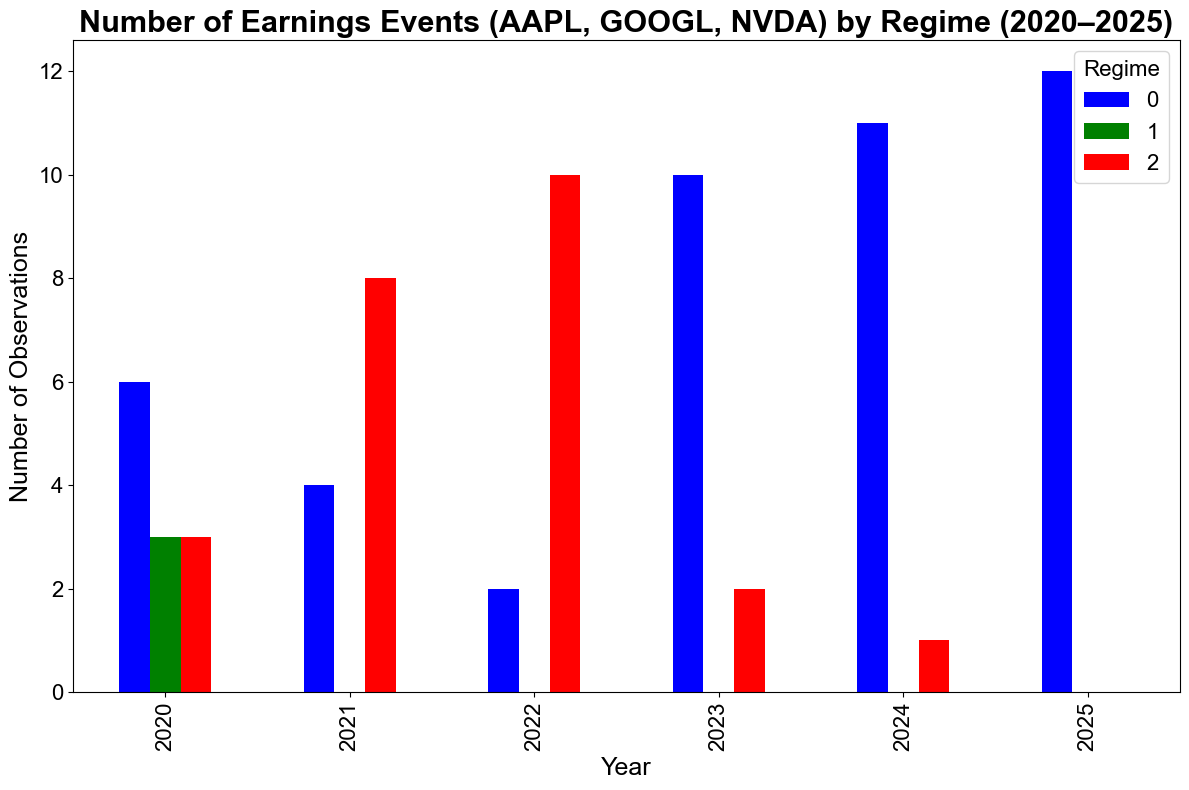

In [7]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Arial'

regime_2020_2025 = regime_counts.loc[2020:2025]

# Match k-means colour scheme exactly
colors = ['blue', 'green', 'red']

ax = regime_2020_2025.plot(
    kind='bar',
    figsize=(12, 8),
    color=colors
)

# Titles and labels – scaled up to match k-means chart
ax.set_title(
    'Number of Earnings Events (AAPL, GOOGL, NVDA) by Regime (2020–2025)',
    fontsize=22,
    fontweight='bold'
)
ax.set_xlabel('Year', fontsize=18)
ax.set_ylabel('Number of Observations', fontsize=18)

# Tick labels
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

# Legend
ax.legend(
    title='Regime',
    fontsize=16,
    title_fontsize=16
)

plt.tight_layout()
plt.savefig('regime_count.png', dpi=300, bbox_inches="tight")
plt.show()